# Chapter 62 — Piecewise Functions

> **Prerequisites:** ch051 (Functions), ch053 (Domain), ch056 (Visualization)
>
> **You will learn:**
> - Define functions that use different rules on different parts of the domain
> - Implement piecewise functions efficiently with NumPy
> - Identify continuity and discontinuity at the boundary points
> - Connect to ReLU and other ML activation functions
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **piecewise function** applies different formulas on different intervals of the domain.

General form: f(x) = { f₁(x) if x ∈ A₁; f₂(x) if x ∈ A₂; ... }

Examples:
- |x| = { x if x ≥ 0; -x if x < 0 }
- ReLU(x) = max(0, x) = { x if x ≥ 0; 0 if x < 0 }
- Floor, ceiling, sign functions are piecewise

**Continuity at boundaries:** A piecewise function is continuous at a boundary point a if the left and right limits agree and equal f(a). If they disagree, there is a jump discontinuity.

**Computational importance:** Piecewise functions arise everywhere in ML:
- ReLU and its variants are the most common neural activation functions
- Decision trees partition the input space and apply constant functions per region
- Clipping (gradient clipping, value clipping) is a piecewise operation

---

## 2. Intuition & Mental Models

**Physical analogy:** A tax bracket system. Different income ranges are taxed at different rates. The total tax function is piecewise linear — each bracket has its own slope.

**Computational analogy:** An `if-else` chain in code is exactly a piecewise function. `if x > 0: return x else: return 0` is ReLU. The mathematical and computational representations are identical.

---

## 3. Visualization

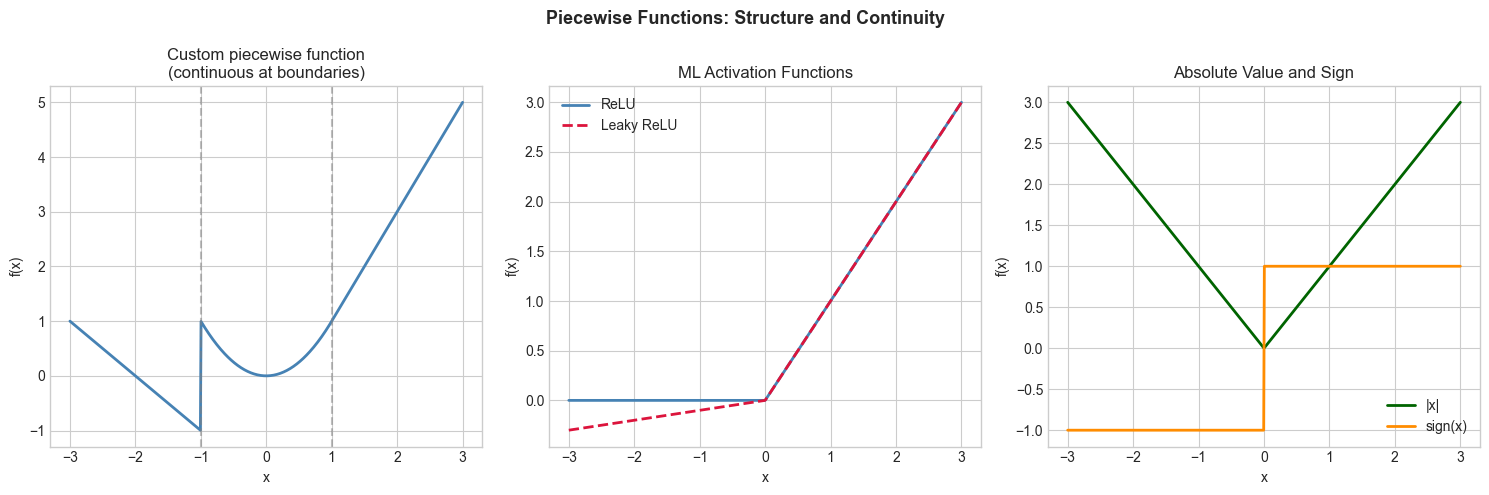

In [1]:
# --- Visualization: Piecewise functions and continuity ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-3, 3, 600)

def piecewise_demo(x):
    return np.piecewise(x,
        [x < -1, (x >= -1) & (x < 1), x >= 1],
        [lambda x: -x - 2,
         lambda x: x**2,
         lambda x: 2*x - 1])

def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x >= 0, x, alpha * x)
def abs_val(x): return np.abs(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x, piecewise_demo(x), color='steelblue', linewidth=2)
axes[0].axvline(-1, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Custom piecewise function\n(continuous at boundaries)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

for ax, (f, label, color) in zip([axes[1]]*3+[axes[2]]*2, [
    (relu, 'ReLU', 'steelblue'),
    (leaky_relu, 'Leaky ReLU (α=0.1)', 'crimson'),
    (abs_val, '|x|', 'darkgreen'),
]):
    pass  # handled below

axes[1].plot(x, relu(x), color='steelblue', linewidth=2, label='ReLU')
axes[1].plot(x, leaky_relu(x), color='crimson', linewidth=2, linestyle='--', label='Leaky ReLU')
axes[1].set_title('ML Activation Functions')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)')
axes[1].legend()

axes[2].plot(x, abs_val(x), color='darkgreen', linewidth=2, label='|x|')
axes[2].plot(x, np.where(x >= 0, 1, -1), color='darkorange', linewidth=2, label='sign(x)')
axes[2].set_title('Absolute Value and Sign')
axes[2].set_xlabel('x'); axes[2].set_ylabel('f(x)')
axes[2].legend()

plt.suptitle('Piecewise Functions: Structure and Continuity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Continuity test at x = a:**
lim_{x→a⁻} f(x) = lim_{x→a⁺} f(x) = f(a)

If the left and right limits differ: **jump discontinuity**.
If they agree but ≠ f(a): **removable discontinuity**.

`np.piecewise(x, conditions, functions)` is the vectorized implementation.

In [2]:
# --- Implementation: Piecewise function with continuity check ---
import numpy as np

def piecewise_fn(x):
    """Example piecewise function: linear-quadratic-linear."""
    x = np.asarray(x, dtype=float)
    return np.piecewise(x,
        [x < -1, (x >= -1) & (x < 1), x >= 1],
        [lambda x: -x, lambda x: x**2, lambda x: x])

def check_continuity(f, boundary, eps=1e-8):
    """Numerically check continuity at a boundary point."""
    left_limit = f(boundary - eps)
    right_limit = f(boundary + eps)
    value = f(boundary)
    continuous = (np.abs(left_limit - right_limit) < 1e-6 and
                  np.abs(value - right_limit) < 1e-6)
    return continuous, left_limit, right_limit, value

for boundary in [-1, 0, 1]:
    cont, ll, rl, val = check_continuity(piecewise_fn, boundary)
    print(f"At x={boundary}: left={ll:.4f}, right={rl:.4f}, f({boundary})={val:.4f} => {'CONTINUOUS' if cont else 'DISCONTINUOUS'}") 

At x=-1: left=1.0000, right=1.0000, f(-1)=1.0000 => CONTINUOUS
At x=0: left=0.0000, right=0.0000, f(0)=0.0000 => CONTINUOUS
At x=1: left=1.0000, right=1.0000, f(1)=1.0000 => CONTINUOUS


---

## 6. Experiments

**Experiment 1:** Modify piecewise_demo to create a discontinuity at x=1. Change the right piece to `2*x - 2` instead of `2*x - 1`. Observe the jump visually.

**Experiment 2:** Compare ReLU and Leaky ReLU at x=-1, -0.1, 0. What happens to very negative inputs under standard ReLU? (This is the 'dying ReLU' problem in deep learning.)

---

## 7. Exercises

**Easy 1.** Write a piecewise function for the absolute value |x| without using `abs` or `np.abs`. Test on [-3, -1, 0, 1, 3].

**Easy 2.** Implement the tax function: 10% on first $20k, 25% on $20k-$80k, 40% above $80k. Test on incomes [0, 10000, 30000, 100000].

**Medium 1.** Implement the Huber loss: L(x) = { x²/2 if |x|≤δ; δ(|x| - δ/2) if |x|>δ }. Plot for δ=1 and compare to |x|. Where is it smooth?

**Medium 2.** Implement `smooth_piecewise(f1, f2, boundary, width)` that smoothly blends f1 and f2 near the boundary using a sigmoid transition.

**Hard.** The sign function sign(x) is discontinuous at x=0. Implement a smooth approximation sign_smooth(x, k) = tanh(kx) that converges to sign(x) as k→∞. Plot for k=1, 5, 20, 100.

---

## 9. Chapter Summary & Connections

- Piecewise functions use different rules on different intervals
- `np.piecewise` and `np.where` are the NumPy idioms for vectorized piecewise computation
- Continuity at boundaries: check left and right limits numerically
- ReLU, Leaky ReLU, step functions are all piecewise — the foundations of modern ML activations

**Forward connections:**
- ch063 (Step Functions) deepens the discontinuity analysis
- ch065 (Activation Functions in ML) catalogs the full family of ML activations
- Piecewise linear functions form decision tree models in ch293 (Classification)